<a href="https://colab.research.google.com/github/pradipdas9040/Machine-Learning-2/blob/main/AgenticAI/07_persistence_chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
!pip install langchain-ollama

In [2]:
%%capture
!sudo apt-get install -y zstd

In [3]:
%%capture
!curl -fsSL https://ollama.com/install.sh | sh

In [4]:
# Start Ollama service in the background
import subprocess
import os

# Set OLLAMA_HOST to '0.0.0.0' to make it accessible from inside the Colab VM.
os.environ['OLLAMA_HOST'] = '0.0.0.0'

# Terminate existing Ollama process if running
if 'ollama_process' in globals() and ollama_process.poll() is None:
    ollama_process.terminate()
    ollama_process.wait()
    print("Previous Ollama server terminated.")

# Start Ollama server in a new process
ollama_process = subprocess.Popen(['ollama', 'serve'])

# Wait a bit for the server to start (adjust if needed)
import time
time.sleep(10) # Increased sleep time for server to fully initialize

print("Ollama server started.")

Ollama server started.


In [5]:
%%capture
!ollama pull llama2:7b-chat

In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
import operator
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

In [7]:
llm = ChatOllama(
    model="llama2:7b-chat",
    temperature=0.7 # A higher temperature for more creative generation
)

In [8]:
class JokeState(TypedDict):
  topic: str
  joke: str
  explanation: str

In [9]:
def generate_joke(state: JokeState):
  topic = state["topic"]
  prompt = f"Generate a joke on the topic {topic}"
  responce = llm.invoke(prompt).content
  return {"joke": responce}

def generate_explanation(state: JokeState):
  joke = state["joke"]
  prompt = f"Write an explanation for the joke - {joke}"
  responce = llm.invoke(prompt).content
  return {"explanation": responce}

In [10]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explanation", generate_explanation)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge("generate_explanation", END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

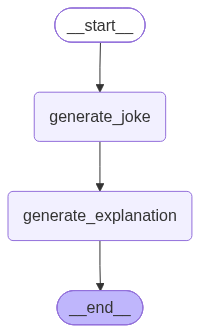

In [11]:
workflow

In [12]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({"topic": "pizza"}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to therapy? It had a crust issue!',
 'explanation': '\nThe joke "Why did the pizza go to therapy?" "It had a crust issue!" is a play on words that combines two different meanings of the word "crust." The first meaning is the outer layer of a pizza, which is the physical structure that holds the toppings. The second meaning is a slang term for a psychological problem or difficulty, often used in a humorous or ironic way.\n\nThe joke works by playing on the multiple meanings of the word "crust" and creating a pun that combines them. The pizza goes to therapy because it has a "crust issue," which could refer to both the physical structure of the pizza and the psychological problem or difficulty that the pizza is experiencing.\n\nThe humor in the joke comes from the unexpected twist on the word "crust" and the absurdity of a pizza seeking therapy. It\'s a lighthearted and silly joke that can bring a smile to the listener\'s face.'}

In [13]:
workflow.get_state(config1) # final stste values

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy? It had a crust issue!', 'explanation': '\nThe joke "Why did the pizza go to therapy?" "It had a crust issue!" is a play on words that combines two different meanings of the word "crust." The first meaning is the outer layer of a pizza, which is the physical structure that holds the toppings. The second meaning is a slang term for a psychological problem or difficulty, often used in a humorous or ironic way.\n\nThe joke works by playing on the multiple meanings of the word "crust" and creating a pun that combines them. The pizza goes to therapy because it has a "crust issue," which could refer to both the physical structure of the pizza and the psychological problem or difficulty that the pizza is experiencing.\n\nThe humor in the joke comes from the unexpected twist on the word "crust" and the absurdity of a pizza seeking therapy. It\'s a lighthearted and silly joke that can bring a smile to the listener\

In [14]:
list(workflow.get_state_history(config1)) # intermidate state values

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy? It had a crust issue!', 'explanation': '\nThe joke "Why did the pizza go to therapy?" "It had a crust issue!" is a play on words that combines two different meanings of the word "crust." The first meaning is the outer layer of a pizza, which is the physical structure that holds the toppings. The second meaning is a slang term for a psychological problem or difficulty, often used in a humorous or ironic way.\n\nThe joke works by playing on the multiple meanings of the word "crust" and creating a pun that combines them. The pizza goes to therapy because it has a "crust issue," which could refer to both the physical structure of the pizza and the psychological problem or difficulty that the pizza is experiencing.\n\nThe humor in the joke comes from the unexpected twist on the word "crust" and the absurdity of a pizza seeking therapy. It\'s a lighthearted and silly joke that can bring a smile to the listener

In [15]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({"topic": "Indian Rail"}, config=config2)

{'topic': 'Indian Rail',
 'joke': 'Why did the Indian Railways train go to the gym?\nTo get some loco-motivation!',
 'explanation': 'The joke "Why did the Indian Railways train go to the gym?" "To get some loco-motivation!" is a play on words that combines two concepts: "loco" (short for "locomotive," which is a type of train) and "motivation." The punchline, "locmo-tivation," is a made-up word that combines the two phrases to create a pun.\n\nThe joke is funny because it takes a common phrase used in fitness (going to the gym for motivation) and gives it a unique twist by replacing "motivation" with "locmo-tivation," which sounds like a made-up word but is actually a clever play on words. The joke works well because it takes advantage of the punny nature of language, making it an enjoyable and humorous punchline for those familiar with both phrases.'}

In [16]:
list(workflow.get_state_history(config2)) # intermidate state values

[StateSnapshot(values={'topic': 'Indian Rail', 'joke': 'Why did the Indian Railways train go to the gym?\nTo get some loco-motivation!', 'explanation': 'The joke "Why did the Indian Railways train go to the gym?" "To get some loco-motivation!" is a play on words that combines two concepts: "loco" (short for "locomotive," which is a type of train) and "motivation." The punchline, "locmo-tivation," is a made-up word that combines the two phrases to create a pun.\n\nThe joke is funny because it takes a common phrase used in fitness (going to the gym for motivation) and gives it a unique twist by replacing "motivation" with "locmo-tivation," which sounds like a made-up word but is actually a clever play on words. The joke works well because it takes advantage of the punny nature of language, making it an enjoyable and humorous punchline for those familiar with both phrases.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f185cb5-c226-6ff9-8002